## **OceanOSSE:** Development Notebook

### **Description:**

Notebook to develop & evaluate Argo profiling float probabillity maps in OceanOSSE.

### **Created By:**

Ollie Tooth (oliver.tooth@noc.ac.uk)

In [19]:
import glob
import logging

import numpy as np
import pandas as pd
import xarray as xr
from sklearn.neighbors import BallTree

from OceanOSSE.io.dataloader import NetCDFDataLoader

In [2]:
logger = logging.getLogger(__name__)

logging.basicConfig(
    format="⦿══⦿  OceanOSSE  ⦿══⦿  ║ %(levelname)10s ║ %(asctime)s ║ %(message)s",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[logging.FileHandler("OceanOSSE.log"), logging.StreamHandler()],
)

### Example configuration .toml file read as dict

In [3]:
config = {
    "domain": {
        "dimensions": {"lev": "deptht", "j": "y", "i": "x"},
        "coordinates": {
            "lat": "nav_lat",
            "lon": "nav_lon",
            "depth": "nav_lev",
        },
        "variables": {
            "tmask": {
                "path": "/dssgfs01/scratch/npd/simulations/Domains/eORCA025/eORCA025_ERA5v1_domain_cfg_mesh_mask_util.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
        },
    },
    "inputs": {
        "dimensions": {"time": "time_counter", "lev": "deptht", "j": "y", "i": "x"},
        "coordinates": {
            "lat": "nav_lat",
            "lon": "nav_lon",
            "depth": "deptht",
            "time": "time_counter",
        },
        "variables": {
            "thetao_con": {
                "path": "/dssgfs01/scratch/npd/simulations/eORCA025_ERA5_v1/eORCA025_ERA5_1m_grid_T_2021*.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
            "so_abs": {
                "path": "/dssgfs01/scratch/npd/simulations/eORCA025_ERA5_v1/eORCA025_ERA5_1m_grid_T_2021*.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
        },
    },
    "climatology": {
        "read_climatology": False,
        "dimensions": {"month": "time_counter", "lev": "deptht", "j": "y", "i": "x"},
        "coordinates": {
            "lat": "nav_lat",
            "lon": "nav_lon",
            "depth": "deptht",
            "month": "time_counter",
        },
        "variables": {
            "thetao_con": {
                "path": "/dssgfs01/scratch/npd/simulations/eORCA025_ERA5_v1/eORCA025_ERA5_1m_grid_T_202*.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
            "so_abs": {
                "path": "/dssgfs01/scratch/npd/simulations/eORCA025_ERA5_v1/eORCA025_ERA5_1m_grid_T_202*.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
        },
    },
    "sampling": {
        "name": "test",
        "error_kernels": [{"name": "test", "kwargs": {"argument": None}}],
    },
    "regridding": {
        "name": "idw",
        "depth_max": 2000.0,
        "mask_name": "tmask",
        },
    "outputs": {
        "output_dir": "/dssgfs01/working/otooth/Software/OceanOSSE/OceanOSSE",
        "output_name": "OceanOSSE_TEST",
        "date_format": "M",
        "chunks": {"time_counter": 12},
        "writer_kwargs": {"unlimited_dims": "time_counter", "mode": "w"},
    },
}

config

{'domain': {'dimensions': {'lev': 'deptht', 'j': 'y', 'i': 'x'},
  'coordinates': {'lat': 'nav_lat', 'lon': 'nav_lon', 'depth': 'nav_lev'},
  'variables': {'tmask': {'path': '/dssgfs01/scratch/npd/simulations/Domains/eORCA025/eORCA025_ERA5v1_domain_cfg_mesh_mask_util.nc',
    'open_kwargs': {'engine': 'netcdf4'}}}},
 'inputs': {'dimensions': {'time': 'time_counter',
   'lev': 'deptht',
   'j': 'y',
   'i': 'x'},
  'coordinates': {'lat': 'nav_lat',
   'lon': 'nav_lon',
   'depth': 'deptht',
   'time': 'time_counter'},
  'variables': {'thetao_con': {'path': '/dssgfs01/scratch/npd/simulations/eORCA025_ERA5_v1/eORCA025_ERA5_1m_grid_T_2021*.nc',
    'open_kwargs': {'engine': 'netcdf4'}},
   'so_abs': {'path': '/dssgfs01/scratch/npd/simulations/eORCA025_ERA5_v1/eORCA025_ERA5_1m_grid_T_2021*.nc',
    'open_kwargs': {'engine': 'netcdf4'}}}},
 'climatology': {'read_climatology': False,
  'dimensions': {'month': 'time_counter', 'lev': 'deptht', 'j': 'y', 'i': 'x'},
  'coordinates': {'lat': 'nav_

### Data Loaders - Input Scalar Fields

In [5]:
dataloader = NetCDFDataLoader.from_config(config=config, table="inputs")

In [6]:
ds = dataloader.load_data()
ds

⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-21 16:58:11 ║ In Progress: Opening variable(s) ['thetao_con', 'so_abs'] from multiple netCDF files '/dssgfs01/scratch/npd/simulations/eORCA025_ERA5_v1/eORCA025_ERA5_1m_grid_T_2021*.nc'
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-21 16:58:18 ║ --> Completed: Opened variable(s) ['thetao_con', 'so_abs'].
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-21 16:58:18 ║ --> Completed: Standardised dataset dimensions ['time', 'lev', 'j', 'i'] and coordinates ['time', 'lat', 'lon', 'depth'].
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-21 16:58:18 ║ --> Completed: Validated standardised dataset.


<xarray.Dataset> Size: 13GB
Dimensions:     (time: 12, lev: 75, j: 1206, i: 1440)
Coordinates:
  * time        (time) datetime64[s] 96B 2021-01-16T12:00:00 ... 2021-12-16T1...
    depth       (lev) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
    lat         (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    lon         (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
Dimensions without coordinates: lev, j, i
Data variables:
    thetao_con  (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>
    so_abs      (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA025_ERA5_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Oct-18 22:35:16 GMT
    uuid:         3595efc2-098e-4efd-b444-cc3268317421

In [7]:
ds["mask"] = ds["thetao_con"].isel(time=0).notnull()

In [ ]:
def _collect_random_sample(ds, n_samples, prob=None):
    """
    Collect random samples from the ocean model grid.

    Parameters
    ----------
    ds : xarray.Dataset
        Input dataset containing ocean model output.
    n_samples : int
        Number of random samples to collect.
    prob : xarray.DataArray, optional
        Probability map for sampling. If None, uniform sampling is used.

    Returns
    -------
    i_prob : np.ndarray
        Array of sampled i indices.
    j_prob : np.ndarray
        Array of sampled j indices.
    """
    # Define surface land-sea mask [0: land, 1: sea]:
    mask = ds["mask"].isel({"lev": 0})

    if prob is None:
        # Create time-independent probability map neglecting land points:
        prob = mask.where(mask == 1).fillna(0)

    # Normalize probability map:
    prob = prob / prob.sum()

    # Flatten the probability map and get the corresponding indices:
    flat_prob = prob.values.flatten()
    flat_indices = np.arange(flat_prob.size)

    # Sample indices based on the probability distribution:
    sampled_indices = np.random.choice(flat_indices, size=n_samples, p=flat_prob)

    # Convert flat indices back to 2D (i, j) coordinates:
    i_prob, j_prob = np.unravel_index(sampled_indices, prob.shape)

    return i_prob, j_prob

In [ ]:
prob = xr.ones_like(ds["lon"]).expand_dims({"month": np.arange(1, 13)}, axis=0)

n_samples = 100
n_profiles = n_samples * ds['time'].size

prof_id = xr.DataArray(np.arange(n_profiles), dims="profile_id")
i_index = xr.DataArray(np.zeros((n_profiles), dtype=int), dims="profile_id", coords={"profile_id": prof_id})
j_index = xr.DataArray(np.zeros((n_profiles), dtype=int), dims="profile_id", coords={"profile_id": prof_id})
t_index = xr.DataArray(np.zeros((n_profiles), dtype=int), dims="profile_id", coords={"profile_id": prof_id})

for t in range(ds['time'].size):
    month = ds["month"].isel({"time": t}).values
    i_index.data[t * n_samples : (t + 1) * n_samples], j_index.data[t * n_samples : (t + 1) * n_samples] = _collect_random_sample(ds, n_samples, prob=prob.sel({"month": month}))

i_index

### ObsSampling

In [4]:
def create_obs_probability_ds(
    longitude: np.ndarray,
    latitude: np.ndarray,
    mask: np.ndarray,
    start_date: str | None = None,
    end_date: str | None = None,
    region: tuple | None = None
    ) -> xr.Dataset:
    """
    Create an xarray.Dataset of monthly count & occurrence probability maps
    defined on a target ocean model grid from Argo profiling observations.

    Parameters
    ----------
    longitude : np.ndarray
        Longitude coordinates defining the target ocean model grid.
    latitude : np.ndarray
        Latitude coordinates defining the target ocean model grid.
    mask : np.ndarray
        2-dimensional land-sea mask defining the target ocean model grid
        (True = ocean, False = land).
    start_date : str | None, optional
        Start date for the time period (inclusive), by default None.
    end_date : str | None, optional
        End date for the time period (inclusive), by default None.
    region : tuple | None, optional
        Geographical region to select Argo profiles from given by a bounding
        box in the form (min_lon, min_lat, max_lon, max_lat), by default None.

    Returns
    -------
    xr.Dataset
        Count & probability maps defined on a target ocean model grid.
    """
    # --- Optionally Apply Region to Land-Sea Mask --- #
    # Defining shape of geographical coordinates:
    if longitude.shape != latitude.shape:
        raise ValueError(
            "Longitude and latitude coordinates of the ocean model grid must have the same shape."
        )
    ny, nx = longitude.shape

    # --- Collect Ocean Grid Points --- #
    # Collect indices of wet grid points within regional subdomain:
    index_flat_idx = np.flatnonzero(mask.ravel())
    grid_points = np.column_stack(
        [latitude.ravel()[index_flat_idx], longitude.ravel()[index_flat_idx]]
    )

    # GeoBallTree: haversine-distance BallTree over wet ocean points only:
    geoballtree = BallTree(np.deg2rad(grid_points), metric="haversine")

    # --- Open Argo Profiling DataFrame --- #
    # Open Argo profile database from JASMIN OS:
    df = pd.read_parquet("https://noc-msm-o.s3-ext.jc.rl.ac.uk/ocean-obs/OceanOSSE/EN.4.2.2.f.profiles.g10.2001_2026.parquet")
    df["month"] = df["JULD"].dt.month

    if start_date is not None:
        df = df[df["JULD"] >= pd.Timestamp(start_date)]
    if end_date is not None:
        df = df[df["JULD"] <= pd.Timestamp(end_date)]

    if region is not None:
        df = df[
            (df["LATITUDE"] >= region[1])
            & (df["LATITUDE"] <= region[3])
            & (df["LONGITUDE"] >= region[0])
            & (df["LONGITUDE"] <= region[2])
        ]

    if len(df) == 0:
        raise ValueError(
            f"No Argo profiles found within time period {start_date or df['JULD'].min()} to {end_date or df['JULD'].max()}."
        )

    # -- Identify ocean model grid  (j, i) indices for each Argo profile -- #
    # Define Argo profile coordinates:
    obs_points = np.column_stack([df["LATITUDE"], df["LONGITUDE"]])
    # Find nearest wet grid cell for each Argo profile:
    ind = geoballtree.query(np.deg2rad(obs_points), k=1, return_distance=False)

    # Transform (regional subdomain) wet grid point indices to ocean model grid indices:
    flat_idx_full = index_flat_idx[ind[:, 0]]
    iy, ix = np.unravel_index(flat_idx_full, latitude.shape)
    df["iy"] = iy
    df["ix"] = ix

    # -- Count Argo profiles for each month -- #
    counts = np.zeros((12, ny, nx), dtype=np.int32)
    for m in range(1, 13):
        df_month = df[df["month"] == m]
        if len(df_month) == 0:
            continue
        # Add counts of Argo profiles to wet grid cells:
        np.add.at(counts[m - 1], (df_month["iy"].values, df_month["ix"].values), 1)

    # -- Construct xarray Dataset of monthly probabilities -- #
    # Create Dataset with total monthly Argo profile counts:
    ds_out = xr.Dataset(
        {
         "counts": (["month", "j", "i"], counts)
         },
        coords={
            "month": np.arange(1, 13),
            "lat": (["j", "i"], latitude),
            "lon": (["j", "i"], longitude),
        },
    )
    # Add `count` variable attributes:
    ds_out["counts"].attrs = {
        "long_name": "Monthly Argo Profile Count",
        "units": "1",
    }

    # Compute monthly Argo profile occurrence probability:
    ds_out["probability"] = ds_out["counts"] / ds_out["counts"].sum(dim=("j", "i"))
    # Add `probability` variable attributes:
    ds_out["probability"].attrs = {
        "long_name": "Monthly Argo Profile Occurrence Probability",
        "units": "1",
    }

    return ds_out

In [10]:
ds_prob = create_obs_probability_ds(longitude=ds["lon"].values,
                                    latitude=ds["lat"].values,
                                    mask=ds["mask"][0, :, :].values,
                                    start_date="2004-01",
                                    end_date="2026-12",
                                    )

ds_prob

<xarray.Dataset> Size: 264MB
Dimensions:      (month: 12, j: 1206, i: 1440)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    lat          (j, i) float32 7MB -89.5 -89.5 -89.5 -89.5 ... 0.0 0.0 0.0 0.0
    lon          (j, i) float32 7MB 73.0 73.25 73.5 73.75 ... 0.0 0.0 0.0 0.0
Dimensions without coordinates: j, i
Data variables:
    counts       (month, j, i) int32 83MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    probability  (month, j, i) float64 167MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

Text(0, 0.5, 'Model j-index')

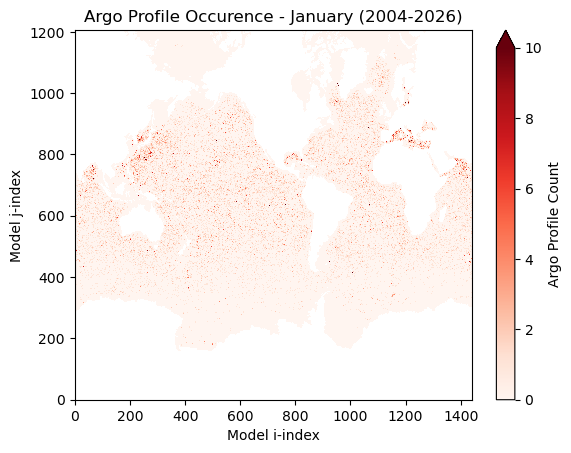

In [18]:
import matplotlib.pyplot as plt

ds_prob["counts"][0, :, :].where(ds["mask"][0, :, :]).plot(cmap="Reds", cbar_kwargs={"label": "Argo Profile Count"}, vmax=10)

plt.title("Argo Profile Occurence - January (2004-2026)")
plt.xlabel("Model i-index")
plt.ylabel("Model j-index")

In [20]:
def create_obs_profile_ds(
    start_date: str | None = None,
    end_date: str | None = None,
    region: tuple | None = None
    ) -> xr.Dataset:
    """
    Create an xarray.Dataset of historical Argo profile observations.

    Parameters
    ----------
    start_date : str | None, optional
        Start date for the time period (inclusive), by default None
    end_date : str | None, optional
        End date for the time period (inclusive), by default None
    region : tuple | None, optional
        Subregion of the model grid with lat/lon bounding box in the form 
        (min_lon, min_lat, max_lon, max_lat), by default None

    Returns
    -------
    xr.Dataset
        Historical Argo profile times & locations.
    """
    # --- Open Argo Profiling DataFrame --- #
    # Open Argo profile database from JASMIN OS:
    df = pd.read_parquet("https://noc-msm-o.s3-ext.jc.rl.ac.uk/ocean-obs/OceanOSSE/EN.4.2.2.f.profiles.g10.2001_2026.parquet")
    df["month"] = df["JULD"].dt.month

    if start_date is not None:
        df = df[df["JULD"] >= pd.Timestamp(start_date)]
    if end_date is not None:
        df = df[df["JULD"] <= pd.Timestamp(end_date)]

    if region is not None:
        df = df[
            (df["LATITUDE"] >= region[1])
            & (df["LATITUDE"] <= region[3])
            & (df["LONGITUDE"] >= region[0])
            & (df["LONGITUDE"] <= region[2])
        ]

    if len(df) == 0:
        raise ValueError(
            f"No Argo profiles found within time period {start_date or df['JULD'].min()} to {end_date or df['JULD'].max()}."
        )

    # -- Construct xarray Dataset of Historical Argo profiles -- #
    ds_out = xr.Dataset(data_vars=dict(lon=(("profile_id"), df["LONGITUDE"]),
                                       lat=(("profile_id"), df["LATITUDE"]),
                                       time=(("profile_id"), df["JULD"])),
                        coords=dict(profile_id=df["ID"])
                        )

    return ds_out

### Existing Code

In [ ]:
"""
Build monthly Argo profile locations (sampling-probability maps) on a NEMO model grid.

Generalised so the user can specify:
  1. A time period (start_date / end_date) to construct monthly counts
  2. An optional subregion of the ocean model grid (lat/lon bounding
     box) to restrict the analysis to.

Usage: edit the CONFIG block below, then run the script.
"""
# Column in the parquet data holding the profile date/time
DATE_COL = "JULD"  # change if needed, e.g. "TIME"

# --- Time period -----------------------------------------------------------
# Set to None to use the full range of dates present in the data.
# Otherwise use "YYYY-MM-DD" strings (inclusive of both ends).
START_DATE = None  # e.g. "2010-01-01"
END_DATE = None    # e.g. "2015-12-31"

# --- Subregion ---------------------------------------------------------
# Set REGION to None to use the full model grid.
# Otherwise provide a dict with lat/lon bounding box (degrees).
# Longitudes should be in the same convention as glamt (e.g. for NEMO its -180..180
# or 0..360 — check ds_domain["glamt"] if unsure).
REGION = None
#REGION = {"lat_min": 10, "lat_max": 50, "lon_min": -30, "lon_max": 10}

# Example: REGION = {"lat_min": -10, "lat_max": 10, "lon_min": -30, "lon_max": 20}

# ─────────────────────────────────────────────────────────────────────────
# 1. Load model grid (domain_cfg), build a WET-POINT-ONLY land-sea mask,
#    and optionally subset to REGION
# ─────────────────────────────────────────────────────────────────────────

#ds_domain = xr.open_zarr(f"{domain_URL}", consolidated=True, chunks={})
#ds_domain = xr.open_dataset("/dssgfs01/working/shapat/OSSE/OceanOSSE/OceanOSSE/sampling/argo/data/profiles_g10/mesh_mask.nc")
ds_domain = xr.open_dataset("/dssgfs01/scratch/npd/simulations/Domains/eORCA025/domain_cfg.nc")
lon_model = ds_domain["glamt"][0,:,:].values
lat_model = ds_domain["gphit"][0,:,:].values

ny, nx = lat_model.shape

# --- Build a surface T-point wet mask (True = ocean, False = land) --------
# Different domain_cfg / mesh_mask files expose this differently, so try
# the common variants in order of preference.
if "top_level" in ds_domain:
    # top_level == 0 at a T-point means it is permanently land
    wet_mask = (ds_domain["top_level"].values > 0)
elif "bottom_level" in ds_domain:
    wet_mask = (ds_domain["bottom_level"].values > 0)
elif "tmask" in ds_domain:
    tmask = ds_domain["tmask"].values
    # tmask is (t, z, y, x) ; take surface level
    if tmask.ndim == 4:
        wet_mask = tmask[0, 0] > 0
    elif tmask.ndim == 3:
        wet_mask = tmask[0] > 0
    else:
        wet_mask = tmask > 0
else:
    raise KeyError(
        "Could not find a land-sea mask variable in domain_cfg "
        "(looked for 'top_level', 'bottom_level', 'tmask'). Inspect "
        "ds_domain.data_vars and set wet_mask manually."
    )

wet_mask = wet_mask.astype(bool)
if not wet_mask.any():
    raise ValueError("Wet mask is empty — check the mask variable/logic above.")

print(f"Wet T-points: {wet_mask.sum()} / {wet_mask.size} grid cells")

# --- Apply optional subregion on top of the wet mask -----------------------
if REGION is not None:
    region_box = (
        (lat_model >= REGION["lat_min"])
        & (lat_model <= REGION["lat_max"])
        & (lon_model >= REGION["lon_min"])
        & (lon_model <= REGION["lon_max"])
    )
    if not region_box.any():
        raise ValueError(
            "REGION bounding box does not overlap the model grid — check "
            "lat/lon ranges and longitude convention (e.g. -180..180 vs 0..360)."
        )
    index_mask = wet_mask & region_box
    
    if not index_mask.any():
        raise ValueError(
            "REGION bounding box contains no wet ocean points — check the "
            "bounding box, or it may fall entirely on land."
        )
else:
    index_mask = wet_mask

# --- After building index_mask, get the tight 2D bounding slice ---
if REGION is not None:
    rows_with_data = np.where(index_mask.any(axis=1))[0]
    cols_with_data = np.where(index_mask.any(axis=0))[0]
    row_min, row_max = rows_with_data[0], rows_with_data[-1] + 1
    col_min, col_max = cols_with_data[0], cols_with_data[-1] + 1
else:
    row_min, col_min = 0, 0
    row_max, col_max = ny, nx

# Cropped grid metadata (used when saving NetCDF)
lat_save = lat_model[row_min:row_max, col_min:col_max]
lon_save = lon_model[row_min:row_max, col_min:col_max]
ny_save  = row_max - row_min
nx_save  = col_max - col_min

# Flat indices of cells eligible for nearest-neighbour matching: wet,
# and inside REGION if one was given. Land points are NEVER included,
# so a query can never return a land cell as "nearest".
index_flat_idx = np.flatnonzero(index_mask.ravel())
grid_points = np.column_stack(
    [lat_model.ravel()[index_flat_idx], lon_model.ravel()[index_flat_idx]]
)

# GeoBallTree: haversine-distance BallTree over wet ocean points only.
# wet-only point set so land cells can never be returned as "nearest".)
tree = BallTree(np.deg2rad(grid_points), metric="haversine")

# ─────────────────────────────────────────────────────────────────────────
# 2. Load Argo profile data
# ─────────────────────────────────────────────────────────────────────────

files = sorted(glob.glob(PROFILE_GLOB))
if not files:
    raise FileNotFoundError(f"No parquet files matched: {PROFILE_GLOB}")

df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

# ─────────────────────────────────────────────────────────────────────────
# 3. Parse date, filter to requested time period, extract MONTH
# ─────────────────────────────────────────────────────────────────────────

df[DATE_COL] = pd.to_datetime(df[DATE_COL])

if START_DATE is not None:
    df = df[df[DATE_COL] >= pd.Timestamp(START_DATE)]
if END_DATE is not None:
    df = df[df[DATE_COL] <= pd.Timestamp(END_DATE)]

if len(df) == 0:
    raise ValueError(
        "No profiles remain after applying START_DATE/END_DATE filter — "
        "check the requested time period against the data's date range."
    )

df["MONTH"] = df[DATE_COL].dt.month

print("Profiles after time filtering:", len(df))
print(df["MONTH"].value_counts().sort_index())

# ─────────────────────────────────────────────────────────────────────────
# 4. Match each profile to its nearest model grid cell within the region
# ─────────────────────────────────────────────────────────────────────────

obs_points = np.column_stack([df["LATITUDE"], df["LONGITUDE"]])
dist, ind = tree.query(np.deg2rad(obs_points), k=1)

# `ind` indexes into grid_points (i.e. into index_flat_idx — wet points,
# optionally restricted to REGION), so map back to the original flat grid
# index, then to 2D (iy, ix). Because land was excluded when building the
# tree, this can never resolve to a land cell.
flat_idx_full = index_flat_idx[ind[:, 0]]
iy, ix = np.unravel_index(flat_idx_full, lat_model.shape)

# Optional sanity check / diagnostic: how far (km) was each profile from
# its matched wet cell? Useful for spotting coastal profiles assigned to
# a wet cell far away because of a coarse grid.
EARTH_RADIUS_KM = 6371.0
match_dist_km = dist[:, 0] * EARTH_RADIUS_KM
print(
    f"Nearest-wet-cell distance (km): "
    f"mean={match_dist_km.mean():.1f}, max={match_dist_km.max():.1f}"
)

df["iy"] = iy
df["ix"] = ix

# ─────────────────────────────────────────────────────────────────────────
# 5. Build monthly counts (full grid shape; cells outside REGION stay zero)
# ─────────────────────────────────────────────────────────────────────────

counts = np.zeros((12, ny_save, nx_save), dtype=np.float32)
for m in range(1, 13):
    subset = df[df["MONTH"] == m]
    if len(subset) == 0:
        continue
     # Shift indices into the cropped coordinate frame
    iy_crop = subset["iy"].values - row_min
    ix_crop = subset["ix"].values - col_min
    np.add.at(counts[m - 1], (iy_crop, ix_crop), 1)
    #np.add.at(counts[m - 1], (subset["iy"].values, subset["ix"].values), 1)

print("Total profiles mapped:", counts.sum())
print("Counts per month:", counts.sum(axis=(1, 2)))

# ─────────────────────────────────────────────────────────────────────────
# 6. Convert counts to probabilities (normalised within region, per month)
# ─────────────────────────────────────────────────────────────────────────

month_totals = counts.sum(axis=(1, 2), keepdims=True)
month_totals = np.where(month_totals == 0, 1, month_totals)
prob = counts / month_totals

# ─────────────────────────────────────────────────────────────────────────
# 7. Save as NetCDF, with metadata describing the time period / region used
# ─────────────────────────────────────────────────────────────────────────

ds_prob = xr.Dataset(
    {"argo_probability": (["month", "y", "x"], prob)},
    coords={
        "month": np.arange(1, 13),
        "lat_model": (["y", "x"], lat_save),
        "lon_model": (["y", "x"], lon_save),
    },
)

actual_start = df[DATE_COL].min().strftime("%Y-%m-%d")
actual_end = df[DATE_COL].max().strftime("%Y-%m-%d")

ds_prob["argo_probability"].attrs = {
    "long_name": "Monthly Argo sampling probability",
    "units": "1",
}
ds_prob.attrs["time_period"] = f"{actual_start} to {actual_end}"
ds_prob.attrs["region"] = str(REGION) if REGION is not None else "full model grid"
ds_prob.attrs["matching"] = (
    "Profiles matched to nearest WET T-point only (land-sea masked "
    "GeoBallTree, haversine distance); land cells cannot be assigned."
)

# Build an informative, period/region-aware filename
period_tag = f"{actual_start[:4]}_{actual_end[:4]}"
region_tag = "subregion" if REGION is not None else "full"
out_name = f"argo_probability_NEMO025_grid_{period_tag}_{region_tag}.nc"
out_path = f"{OUTPUT_DIR}/{out_name}"

ds_prob.to_netcdf(out_path)
print(f"Saved: {out_path}")

In [ ]:
ds.time.max().dt.strftime("%Y-%m-%d").item()